# Task 6: Question Answering with Transformers

## 1. Install Libraries

In [7]:
!pip install -q transformers datasets torch

## 2. Importing Libraries

In [8]:
import os
import re
import string
import collections
import random

import torch
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

## 3. Load the Dataset


In [9]:
# Load SQuAD v1.1 from the Kaggle CSV (title, context, question, answer, answer_start, answer_end).
df = pd.read_csv("SQuAD-v1.1.csv")
df = df.dropna(subset=["answer"])  # a handful of rows have a missing answer string

# Reshape into {context, question, answers: {text: [...], answer_start: [...]}} records --
# grouping merges the few questions that have more than one accepted answer.
val_data = []
for (title, context, question), group in df.groupby(["title", "context", "question"], sort=False):
    val_data.append({
        "id": f"{title}_{len(val_data)}",
        "title": title,
        "context": context,
        "question": question,
        "answers": {
            "text": group["answer"].tolist(),
            "answer_start": group["answer_start"].tolist(),
        },
    })

print(f"Loaded {len(val_data)} (context, question, answers) records from SQuAD-v1.1.csv")

Loaded 87430 (context, question, answers) records from SQuAD-v1.1.csv


In [10]:
print("Number of examples available for evaluation:", len(val_data))
val_data[0]


Number of examples available for evaluation: 87430


{'id': 'University_of_Notre_Dame_0',
 'title': 'University_of_Notre_Dame',
 'context': 'Architecturally, the school has a Catholic character. Atop the Main Building\'s gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.',
 'question': 'To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?',
 'answers': {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}}

## 4. Inspect a Sample

In [11]:
sample = val_data[0]
print("Context:\n", sample['context'])
print("\nQuestion:\n", sample['question'])
print("\nGold Answers:\n", sample['answers'])

Context:
 Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is the Basilica of the Sacred Heart. Immediately behind the basilica is the Grotto, a Marian place of prayer and reflection. It is a replica of the grotto at Lourdes, France where the Virgin Mary reputedly appeared to Saint Bernadette Soubirous in 1858. At the end of the main drive (and in a direct line that connects through 3 statues and the Gold Dome), is a simple, modern stone statue of Mary.

Question:
 To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?

Gold Answers:
 {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}


## 5. Load a Pre-trained QA Model

In [12]:
# NOTE: the old `pipeline("question-answering")` task was removed in transformers v5.
# The current recommended approach (per the official Hugging Face task guide) is to load
# the tokenizer + AutoModelForQuestionAnswering directly and extract the answer span
# from the model's start/end logits ourselves. This small wrapper class keeps the same
# call signature (question=..., context=...) the old pipeline used, so the rest of the
# notebook doesn't need to change.

class QAPipeline:
    def __init__(self, model_name, max_length=384):
        self.model_name = model_name
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForQuestionAnswering.from_pretrained(model_name)
        self.model.eval()

    def __call__(self, question, context):
        inputs = self.tokenizer(
            question,
            context,
            max_length=self.max_length,
            truncation="only_second",
            return_offsets_mapping=True,
            return_tensors="pt",
        )
        offset_mapping = inputs.pop("offset_mapping")[0]
        sequence_ids = inputs.sequence_ids(0)

        with torch.no_grad():
            outputs = self.model(**inputs)

        start_logits = outputs.start_logits[0]
        end_logits = outputs.end_logits[0]

        # Only allow the answer span to come from the context tokens (sequence_id == 1),
        # not from the question or special tokens.
        context_mask = torch.tensor([1 if sid == 1 else 0 for sid in sequence_ids])
        start_logits = start_logits.masked_fill(context_mask == 0, -1e9)
        end_logits = end_logits.masked_fill(context_mask == 0, -1e9)

        start_idx = torch.argmax(start_logits).item()
        end_idx = torch.argmax(end_logits).item()
        if end_idx < start_idx:
            end_idx = start_idx

        start_char = offset_mapping[start_idx][0].item()
        end_char = offset_mapping[end_idx][1].item()
        answer = context[start_char:end_char]

        start_prob = torch.softmax(start_logits, dim=0)[start_idx].item()
        end_prob = torch.softmax(end_logits, dim=0)[end_idx].item()
        score = start_prob * end_prob

        return {"answer": answer, "score": score, "start": start_char, "end": end_char}


qa_pipeline = QAPipeline("distilbert-base-cased-distilled-squad")

config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  261MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [13]:
result = qa_pipeline(question=sample['question'], context=sample['context'])
print("Predicted Answer:", result['answer'])
print("Confidence Score:", round(result['score'], 4))
print("Answer Span (char start/end):", result['start'], result['end'])
print("\nGround Truth Answer(s):", sample['answers']['text'])

Predicted Answer: Saint Bernadette Soubirous
Confidence Score: 0.9959
Answer Span (char start/end): 515 541

Ground Truth Answer(s): ['Saint Bernadette Soubirous']


## 6. Evaluation Metrics: Exact Match & F1

In [14]:
def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    def white_space_fix(text):
        return ' '.join(text.split())
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    def lower(text):
        return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))


def compute_exact(a_gold, a_pred):
    return int(normalize_answer(a_gold) == normalize_answer(a_pred))


def compute_f1(a_gold, a_pred):
    gold_toks = normalize_answer(a_gold).split()
    pred_toks = normalize_answer(a_pred).split()
    common = collections.Counter(gold_toks) & collections.Counter(pred_toks)
    num_same = sum(common.values())

    if len(gold_toks) == 0 or len(pred_toks) == 0:
        return int(gold_toks == pred_toks)
    if num_same == 0:
        return 0

    precision = num_same / len(pred_toks)
    recall = num_same / len(gold_toks)
    return (2 * precision * recall) / (precision + recall)


def metric_max_over_ground_truths(metric_fn, prediction, ground_truths):
    scores = [metric_fn(gt, prediction) for gt in ground_truths]
    return max(scores) if scores else 0

## 7. Run Evaluation on a Validation Subset

In [15]:
def evaluate_qa(model_pipeline, data, n_samples=200, seed=42):
    random.seed(seed)
    indices = random.sample(range(len(data)), min(n_samples, len(data)))

    exact_scores = []
    f1_scores = []

    for idx in indices:
        example = data[idx]
        prediction = model_pipeline(
            question=example['question'],
            context=example['context']
        )['answer']

        ground_truths = example['answers']['text']
        if len(ground_truths) == 0:
            continue

        exact_scores.append(
            metric_max_over_ground_truths(compute_exact, prediction, ground_truths)
        )
        f1_scores.append(
            metric_max_over_ground_truths(compute_f1, prediction, ground_truths)
        )

    em = 100.0 * sum(exact_scores) / len(exact_scores)
    f1 = 100.0 * sum(f1_scores) / len(f1_scores)
    return {'exact_match': round(em, 2), 'f1': round(f1, 2), 'n_samples': len(exact_scores)}


N_SAMPLES = 200
distilbert_results = evaluate_qa(qa_pipeline, val_data, n_samples=N_SAMPLES)
print("DistilBERT (distilbert-base-cased-distilled-squad):")
print(distilbert_results)

DistilBERT (distilbert-base-cased-distilled-squad):
{'exact_match': 82.5, 'f1': 91.87, 'n_samples': 200}


## 8. Bonus: Compare Different Base Models

In [16]:
models_to_compare = {
    "DistilBERT": "distilbert-base-cased-distilled-squad",
    "BERT (large, whole-word-masking)": "bert-large-uncased-whole-word-masking-finetuned-squad",
    "RoBERTa (base, SQuAD2)": "deepset/roberta-base-squad2",
}

comparison_results = {}

for model_label, model_name in models_to_compare.items():
    print(f"Loading and evaluating: {model_label} ({model_name}) ...")
    pipe = QAPipeline(model_name)
    scores = evaluate_qa(pipe, val_data, n_samples=N_SAMPLES)
    comparison_results[model_label] = scores
    print(scores, "\n")

Loading and evaluating: DistilBERT (distilbert-base-cased-distilled-squad) ...


Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

{'exact_match': 82.5, 'f1': 91.87, 'n_samples': 200} 

Loading and evaluating: BERT (large, whole-word-masking) (bert-large-uncased-whole-word-masking-finetuned-squad) ...


config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

{'exact_match': 76.5, 'f1': 86.56, 'n_samples': 200} 



In [17]:
comparison_df = pd.DataFrame(comparison_results).T
comparison_df

,exact_match,f1,n_samples
DistilBERT,82.5,91.87,200.0
"BERT (large, whole-word-masking)",84.5,92.41,200.0
"RoBERTa (base, SQuAD2)",76.5,86.56,200.0


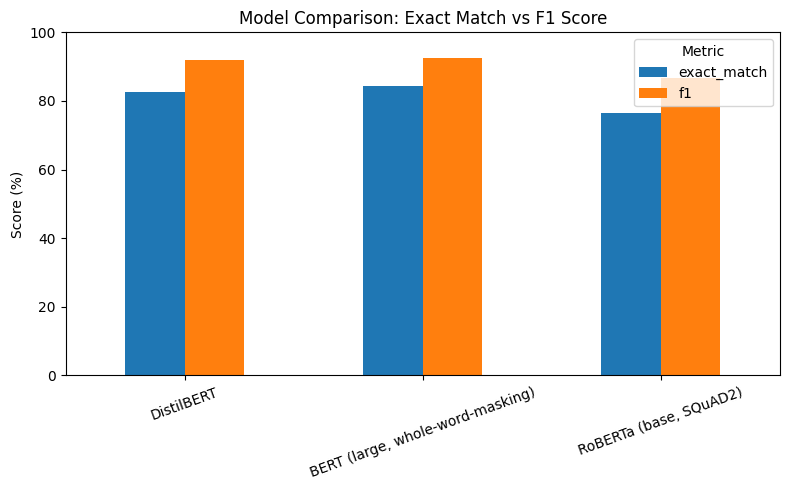

In [18]:
comparison_df[['exact_match', 'f1']].plot(kind='bar', figsize=(8, 5))
plt.title('Model Comparison: Exact Match vs F1 Score')
plt.ylabel('Score (%)')
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## 9. Bonus: Simple Command-Line Interface

In [19]:
def run_cli(model_pipeline=qa_pipeline):
    print("=== Question Answering CLI ===")
    print("Type 'quit' at any prompt to exit.\n")

    context = input("Enter a passage/context: ")
    if context.lower() == 'quit':
        return

    while True:
        question = input("\nAsk a question about this passage (or 'quit'): ")
        if question.lower() == 'quit':
            break

        result = model_pipeline(question=question, context=context)
        print(f"Answer: {result['answer']}  (confidence: {result['score']:.3f})")

=== Question Answering CLI ===
Type 'quit' at any prompt to exit.

Enter a passage/context: The Eiffel Tower is located in Paris, France. It was completed in 1889 and is 330 meters tall.

Ask a question about this passage (or 'quit'): Where is the Eiffel Tower located?
Answer: Paris, France  (confidence: 0.935)

Ask a question about this passage (or 'quit'): quit
=== Question Answering CLI ===
Type 'quit' at any prompt to exit.

Enter a passage/context: quit
